# Resource Selection Function

In [8]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import ee

from movement_models import (
    FeatureSpec,
    _build_design_matrix,
    _get_availability_domain,
    _get_sampling_points,
    _sample_env_layer,
    load_presence_csvs,
    to_reloc_gdf,
    reproject_reloc,
    to_reloc_gdf_projected,
    init_ee,
    init_ee_on_client,
    make_aoi,
    aoi_to_ee,
    build_predictors_image,
    ee_image_to_env_xarray,
    save_env_zarr,
    load_env_zarr,
    shutdown_default_client,
    make_local_dask_client,
    
    fit_rsf,
    predict_rsf_points,
    get_rsf_surface,
    fixed_width_Boyce,
    sliding_window_Boyce,
    cv_model,
    eval_all_linear_candidates
)

In [11]:
client = make_local_dask_client(memory_limit="2GB") 

init_status = init_ee_on_client(client, project_id="ee-alvykabo")
client, init_status

/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 54214 instead
  warnings.warn(


(<Client: 'tcp://127.0.0.1:54215' processes=5 threads=5, memory=9.31 GiB>,
 {'tcp://127.0.0.1:54228': 1,
  'tcp://127.0.0.1:54231': 1,
  'tcp://127.0.0.1:54232': 1,
  'tcp://127.0.0.1:54237': 1,
  'tcp://127.0.0.1:54240': 1})

## speed testing

In [21]:
import time
import pandas as pd

results = []

point_counts = [10_000, 25_000, 50_000, 100_000]

for n in point_counts:
    pts = _get_sampling_points(domain, n, seed=1)

    # 1) fixed small / high-overhead baseline
    t0 = time.perf_counter()
    _ = _sample_env_layer(
        pts,
        env.sel(band=["ndvi", "slope"]),
        chunk_size_points=1_000,
        client=None,
    )
    t1 = time.perf_counter()
    results.append({"n_points": n, "method": "sequential_like", "runtime_sec": t1 - t0})

    # 2) old fixed chunking
    t0 = time.perf_counter()
    _ = _sample_env_layer(
        pts,
        env.sel(band=["ndvi", "slope"]),
        chunk_size_points=20_000,
        client=client,
    )
    t1 = time.perf_counter()
    results.append({"n_points": n, "method": "fixed_dask", "runtime_sec": t1 - t0})

    # 3) new adaptive chunking
    t0 = time.perf_counter()
    _ = _sample_env_layer(
        pts,
        env.sel(band=["ndvi", "slope"]),
        chunk_size_points="auto",
        client=client,
    )
    t1 = time.perf_counter()
    results.append({"n_points": n, "method": "auto_chunk", "runtime_sec": t1 - t0})

bench = pd.DataFrame(results)
bench

Task exception was never retrieved
future: <Task finished name='Task-3481303' coro=<Client._gather.<locals>.wait() done, defined at /opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/distributed/client.py:2399> exception=AllExit()>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/distributed/client.py", line 2408, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

## 1. Preparation

### 1.1 Fetch presence data

In [12]:
reloc_df = load_presence_csvs("data/*.csv")
reloc = to_reloc_gdf(reloc_df)

reloc.head(), reloc.crs, reloc["Timestamp"].dtype

(            Timestamp     ID  Latitude  Longitude                    geometry
 0 2024-05-04 14:31:32  NPL38 -19.50359   14.21912  POINT (14.21912 -19.50359)
 1 2024-05-04 14:32:42  NPL38 -19.50360   14.21912   POINT (14.21912 -19.5036)
 2 2024-05-04 20:37:42  NPL38 -19.51765   14.21877  POINT (14.21877 -19.51765)
 3 2024-05-04 20:38:09  NPL38 -19.51763   14.21878  POINT (14.21878 -19.51763)
 4 2024-05-04 22:43:10  NPL38 -19.47570   14.22619   POINT (14.22619 -19.4757),
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 dtype('<M8[ns]'))

### 1.2 Fetch environmental layers

In [13]:
ee.Authenticate()
init_ee(project_id="ee-alvykabo")   

aoi = make_aoi(reloc, buffer_m=1)
aoi_ee = aoi_to_ee(aoi)

predictors_img = build_predictors_image(aoi_ee, start="2024-01-01", end="2024-12-31")
env = ee_image_to_env_xarray(predictors_img, aoi_ee, crs="EPSG:29333", scale=100, chunk_xy=1024)

save_env_zarr(env, "env_29333.zarr", mode="w")
env2 = load_env_zarr("env_29333.zarr")

env.shape, env.rio.crs, env2.shape

/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


((4, 2663, 2310),
 CRS.from_wkt('PROJCS["Schwarzeck / UTM zone 33S",GEOGCS["Schwarzeck",DATUM["Schwarzeck",SPHEROID["Bessel Namibia (GLM)",6377483.86528042,299.1528128,AUTHORITY["EPSG","7046"]],AUTHORITY["EPSG","6293"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4293"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","29333"]]'),
 (4, 2663, 2310))

## 2. Calculate the RSF

### 2.1 Define the sampling scheme

In [ ]:
domain = _get_availability_domain(reloc)
samples = _get_sampling_points(domain, 1000, df=reloc.iloc[:100], seed=1)
sampled = _sample_env_layer(samples, env.sel(band=["ndvi", "slope"]), chunk_size_points="auto", client=None)

sampled.head()

/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/sampling.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  samples["used"] = samples["used"].fillna(False)


### 2.2 Extract values from the environmental covariates

### 2.3 Fit logistic regression

In [ ]:
spec = FeatureSpec(linear=["ndvi", "slope"], add_const=True)
m, scaler, _ = fit_rsf(sampled, spec)
pred = predict_rsf_points(sampled, m, scaler, spec)

pred[["rsf_pred"]].describe()

### 2.4 Get RSF surface

In [ ]:
rsf = get_rsf_surface(env.sel(band=spec.linear), m, scaler, spec)

rsf

In [ ]:
rsf = get_rsf_surface(env, m, scaler, spec)
rsf = rsf.compute()
rsf.rio.to_raster("rsf.tif", compress="LZW")
rsf = rsf.rio.write_crs("EPSG:29333") 

In [ ]:
client.scheduler_info()["workers"].keys()
len(client.scheduler_info()["workers"])

In [ ]:
import pandas as pd

info = client.scheduler_info()["workers"]

df = pd.DataFrame({
    w: {
        "memory": data["metrics"]["memory"],
        "memory_limit": data["memory_limit"]
    }
    for w, data in info.items()
}).T

df

In [ ]:
df["memory_MB"] = df["memory"] / 1e6
df["limit_MB"] = df["memory_limit"] / 1e6
df[["memory_MB", "limit_MB"]]

### 2.5 Evaluate Using Boyce Index

In [ ]:
subset_predictors = ["ndvi", "ndwi", "slope", "dist2water"]
cov = env.sel(band=subset_predictors)

samples = _get_sampling_points(domain, n=10_000, df=reloc.iloc[:1000], seed=1)
sampled = _sample_env_layer(samples, cov, chunk_size_points="auto", client=client)

spec = FeatureSpec(linear=subset_predictors, add_const=True)
m, scaler, spec = fit_rsf(sampled, spec)

pred = predict_rsf_points(sampled, m, scaler, spec)
rsf = get_rsf_surface(env.sel(band=subset_predictors), m, scaler, spec)

B, boyce = fixed_width_Boyce(pred, rsf, domain, seed=1)
B, boyce.head()

In [ ]:
B, chart = sliding_window_Boyce(
    pred=pred,
    rsf=rsf,
    domain=domain,
    window_frac=0.2,
    step_frac=0.05,
    seed=1,
)

print("B =", B)
print(chart.head())
print("rows:", len(chart), "finite pe:", chart["pe"].notna().sum())

## 3. Aggregate functions

### 3.1 Compare all possible linear models via AIC & BIC

In [ ]:
df_small = sampled.sample(n=min(2000, len(sampled)), random_state=1).copy()
subset_predictors = ["ndvi", "ndwi", "slope", "dist2water"]

df_small = df_small.replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["used"] + subset_predictors)

res = eval_all_linear_candidates(df_small, env, subset=subset_predictors)
res.head()

### 3.2 Cross-Validation on a Single Individual

In [ ]:
res = cv_model(
    obs=reloc,
    env=env,
    k_folds=2,
    subset_predictors=["ndvi", "ndwi", "slope", "dist2water"],
    sampling_factor_train=3,
    n_bg_boyce=5_000,
    seed=1,
)
res

# Step, Length, & Turning Angle

In [2]:
#testing movement_kernel.py with likelihood-based fitting

from movement_models.movement import (
    prepare_trajectory_data,
    build_step_data,
    fit_step_distribution,
    build_turn_angle_data,
    fit_turn_angle_distribution,
    fit_movement_kernel_per_id,
)

from movement_models.io import (
    load_presence_csvs,
    to_reloc_gdf_projected,
)

from movement_models.io import load_presence_csvs
from movement_models.movement import fit_movement_kernel_per_id

reloc = load_presence_csvs("data/*.csv")

out = fit_movement_kernel_per_id(
    reloc,
    id_col="ID",
    timestamp_col="Timestamp",
    lon_col="Longitude",
    lat_col="Latitude",
    target_crs="EPSG:29333",
    expected_interval_min=120,
    tolerance_min=2,
    step_cutoff=20000,
)

out["summary"]

,ID,n_steps,step_distribution,step_q25,step_median,step_mean,step_q75,step_max,n_angles,angle_distribution,step_params,vonmises_kappa,vonmises_mu,mixture_kappa,mixture_w
0,NPL38,2584,lognorm,8.809685,63.692252,546.335874,760.120739,7014.598776,2252,angle_mle,"[2.3680072661020657, 76.329595410113]",0.135231,0.093184,6.79407,0.103583


In [3]:
step_df = out["step_df"]
one_id = step_df["ID"].dropna().iloc[0]
step_subset = step_df.loc[step_df["ID"] == one_id, "step_m"]

fit_step_distribution(step_subset)["model_table"]

,distribution,params,loglik,AIC,success
0,lognorm,"[2.3680072661020657, 76.329595410113]",-17095.920956,34195.841913,True
1,weibull,"[0.4683982286268443, 249.18223047700394]",-17177.628049,34359.256097,True
2,gamma,"[0.3428314692397524, 1593.5262762864115]",-17250.213319,34504.426638,True
3,exp,[546.3358741887124],-18871.556503,37745.113006,True


# testing Bayesian MCMC on the exp model

In [20]:
import importlib
import movement_models.movement.movement_geometry as gm
import movement_models.movement.movement_mle as mle
import movement_models.movement.movement_mh as mh
import movement_models.movement.movement_kernel as mk
importlib.reload(gm)
importlib.reload(mle)
importlib.reload(mh)
importlib.reload(mk)

<module 'movement_models.movement.movement_kernel' from '/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/movement/movement_kernel.py'>

In [15]:

res = mh.fit_exp_distribution_bayes(step_subset)
res

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'exp_bayes',
 'posterior_mean_params': (546.5298889782828,),
 'posterior_median_params': (546.3204463398371,),
 'posterior_q025_params': (525.783178794217,),
 'posterior_q975_params': (567.937217245754,),
 'acceptance_rate': 0.2882,
 'init_scale': 546.3358741887124,
 'proposal_sd': 0.08,
 'prior_scale': 5000.0,
 'samples': array([546.33587419, 546.33587419, 546.33587419, ..., 550.84679417,
        545.436618  , 545.436618  ]),
 'posterior_samples': array([545.01536433, 547.79209677, 547.79209677, ..., 550.84679417,
        545.436618  , 545.436618  ]),
 'log_lik_samples': array([[-7.06324664, -7.47868162, -6.32320554, ..., -6.31305326,
         -6.41307055, -7.19465099],
        [-7.06446374, -7.47779291, -6.32817388, ..., -6.31807306,
         -6.41758337, -7.19520202],
        [-7.06446374, -7.47779291, -6.32817388, ...,

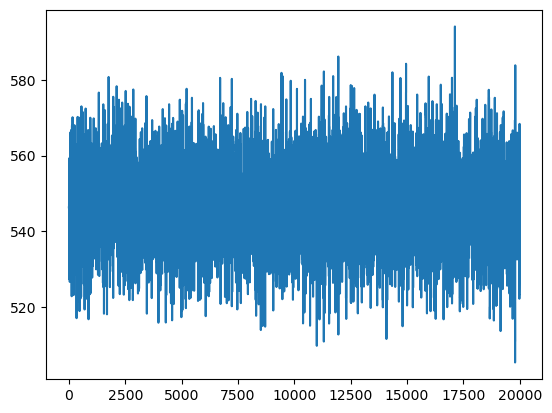

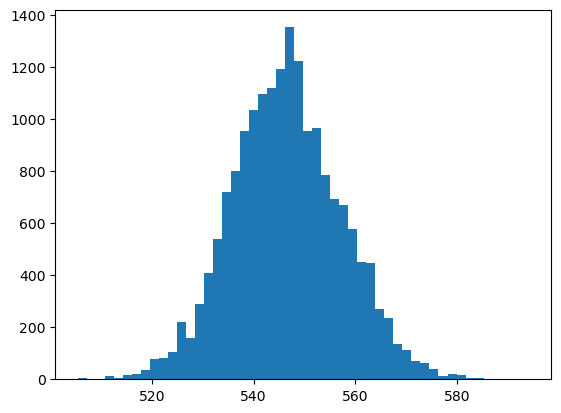

In [16]:
import matplotlib.pyplot as plt

plt.plot(res["samples"])
plt.show()

plt.hist(res["posterior_samples"], bins=50)
plt.show()

# testing Bayesian MCMC on the gamma model

In [19]:
res_gamma = mh.fit_gamma_distribution_bayes(step_subset)

res_gamma

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'gamma_bayes',
 'posterior_mean_params': (0.34292118989146536, 1598.1773374913519),
 'posterior_median_params': (0.34275724859708856, 1596.9856488128198),
 'posterior_q025_params': (0.3284080800503331, 1481.5640937145365),
 'posterior_q975_params': (0.35762155861136713, 1730.32194367599),
 'acceptance_rate': 0.2926,
 'init_params': (1.0, 546.3358741887124),
 'proposal_sd': 0.05,
 'prior_scale': 5000.0,
 'samples': array([[1.00000000e+00, 5.46335874e+02],
        [9.55207421e-01, 5.25919124e+02],
        [9.23716797e-01, 5.70625976e+02],
        ...,
        [3.41546580e-01, 1.58668775e+03],
        [3.41546580e-01, 1.58668775e+03],
        [3.41546580e-01, 1.58668775e+03]]),
 'posterior_samples': array([[3.43842872e-01, 1.58461958e+03],
        [3.43842872e-01, 1.58461958e+03],
        [3.37539089e-01, 1.72481197e+03],
   

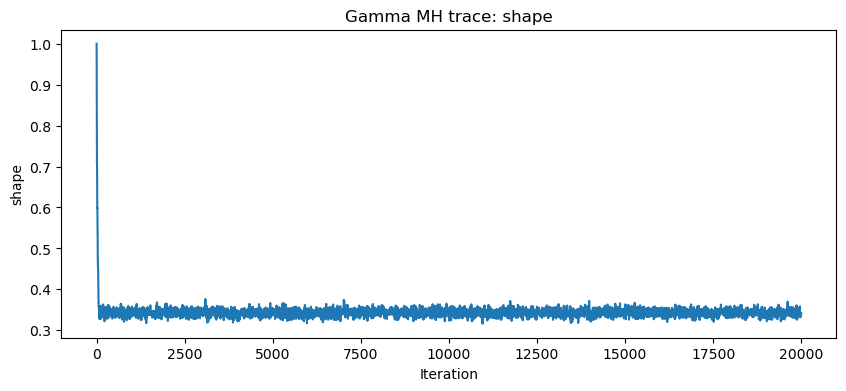

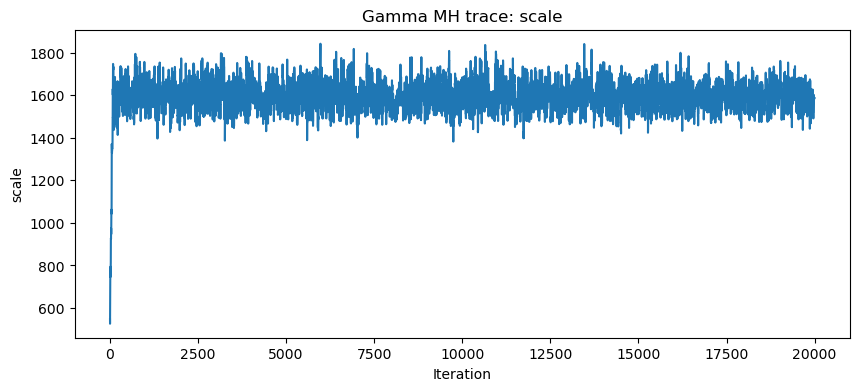

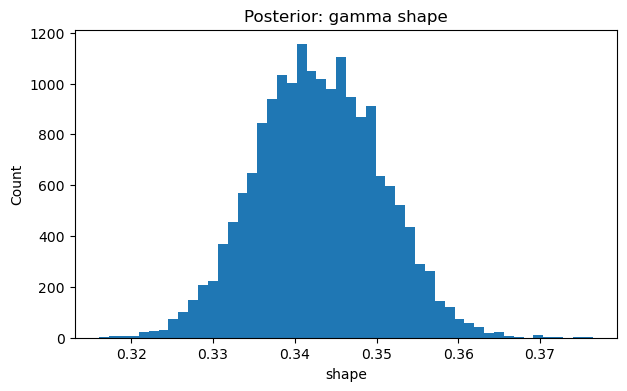

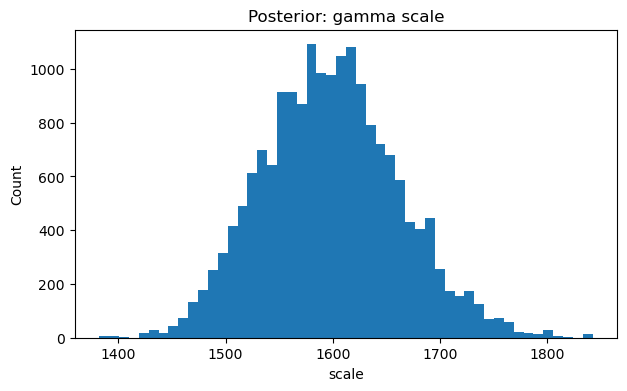

In [20]:
shape_chain = res_gamma["samples"][:, 0]
scale_chain = res_gamma["samples"][:, 1]

plt.figure(figsize=(10, 4))
plt.plot(shape_chain)
plt.xlabel("Iteration")
plt.ylabel("shape")
plt.title("Gamma MH trace: shape")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(scale_chain)
plt.xlabel("Iteration")
plt.ylabel("scale")
plt.title("Gamma MH trace: scale")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_gamma["posterior_samples"][:, 0], bins=50)
plt.xlabel("shape")
plt.ylabel("Count")
plt.title("Posterior: gamma shape")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_gamma["posterior_samples"][:, 1], bins=50)
plt.xlabel("scale")
plt.ylabel("Count")
plt.title("Posterior: gamma scale")
plt.show()

# testing Bayesian MCMC on the weibull model

In [22]:
res_weibull = mh.fit_weibull_distribution_bayes(step_subset)

res_weibull

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'weibull_bayes',
 'posterior_mean_params': (0.4686279953364091, 249.85572620630253),
 'posterior_median_params': (0.46861919426209986, 249.34263046069805),
 'posterior_q025_params': (0.45481920664638315, 228.48844078004655),
 'posterior_q975_params': (0.48240855300387286, 273.38472654024366),
 'acceptance_rate': 0.26515,
 'init_params': (1.0, 546.3358741887124),
 'proposal_sd': 0.05,
 'prior_scale': 5000.0,
 'samples': array([[9.43848364e-01, 5.70546254e+02],
        [9.43848364e-01, 5.70546254e+02],
        [9.16108851e-01, 5.91132049e+02],
        ...,
        [4.83772393e-01, 2.69829827e+02],
        [4.83772393e-01, 2.69829827e+02],
        [4.83772393e-01, 2.69829827e+02]]),
 'posterior_samples': array([[  0.46882514, 241.82897734],
        [  0.46882514, 241.82897734],
        [  0.46882514, 241.82897734],
        ..

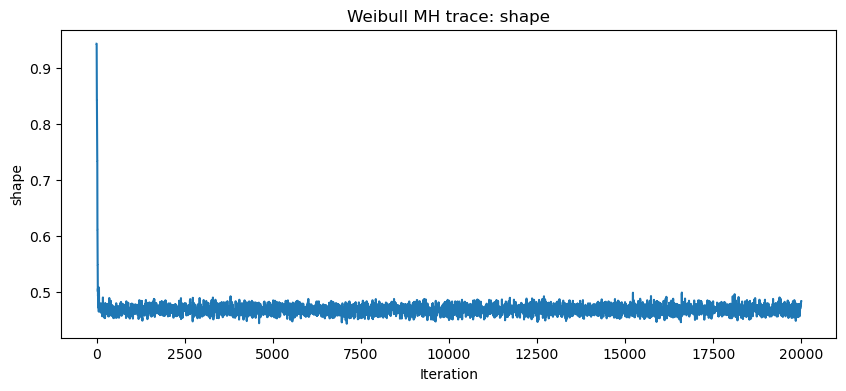

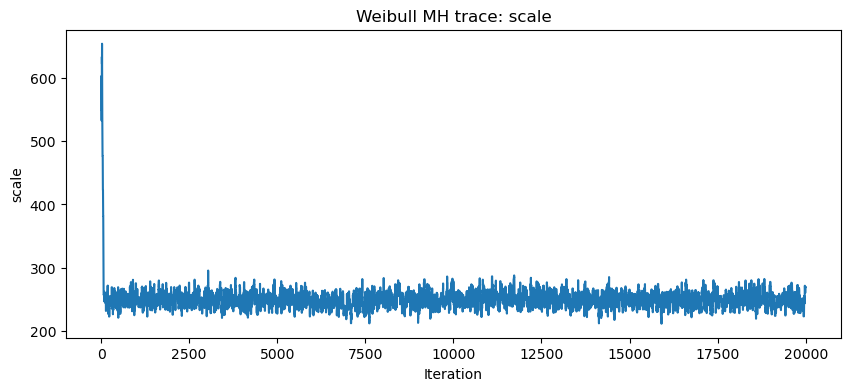

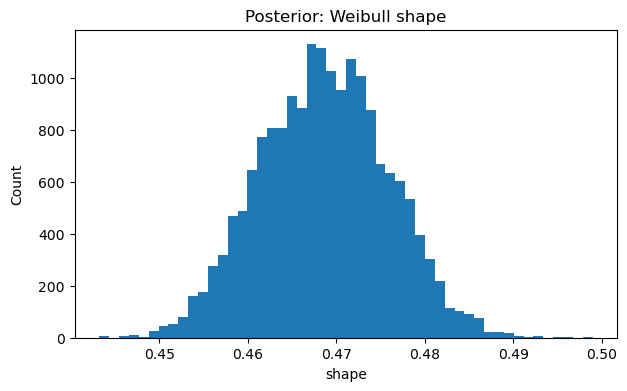

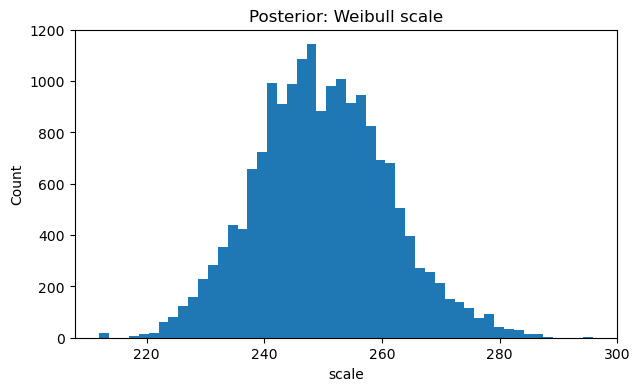

In [23]:
shape_chain = res_weibull["samples"][:, 0]
scale_chain = res_weibull["samples"][:, 1]

plt.figure(figsize=(10, 4))
plt.plot(shape_chain)
plt.xlabel("Iteration")
plt.ylabel("shape")
plt.title("Weibull MH trace: shape")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(scale_chain)
plt.xlabel("Iteration")
plt.ylabel("scale")
plt.title("Weibull MH trace: scale")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_weibull["posterior_samples"][:, 0], bins=50)
plt.xlabel("shape")
plt.ylabel("Count")
plt.title("Posterior: Weibull shape")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_weibull["posterior_samples"][:, 1], bins=50)
plt.xlabel("scale")
plt.ylabel("Count")
plt.title("Posterior: Weibull scale")
plt.show()

# testing Bayesian MCMC on the lognormal model

In [24]:
res_lognorm = mh.fit_lognorm_distribution_bayes(step_subset)

res_lognorm

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'lognorm_bayes',
 'posterior_mean_params': (4.33528112801036, 2.3688348267868045),
 'posterior_median_params': (4.335496369037769, 2.36855138433514),
 'posterior_q025_params': (4.243386379642423, 2.3041722058973932),
 'posterior_q975_params': (4.428874018333379, 2.434488704301177),
 'acceptance_rate': 0.25865,
 'init_params': (4.335074000879982, 1.0),
 'proposal_sd': 0.05,
 'prior_scale': 10.0,
 'samples': array([[4.335074  , 1.        ],
        [4.39431813, 1.03027   ],
        [4.39431813, 1.03027   ],
        ...,
        [4.34545789, 2.35031537],
        [4.30492162, 2.36577903],
        [4.31191161, 2.38022228]]),
 'posterior_samples': array([[4.37323468, 2.40434896],
        [4.38243915, 2.41157565],
        [4.38243915, 2.41157565],
        ...,
        [4.34545789, 2.35031537],
        [4.30492162, 2.36577903],
  

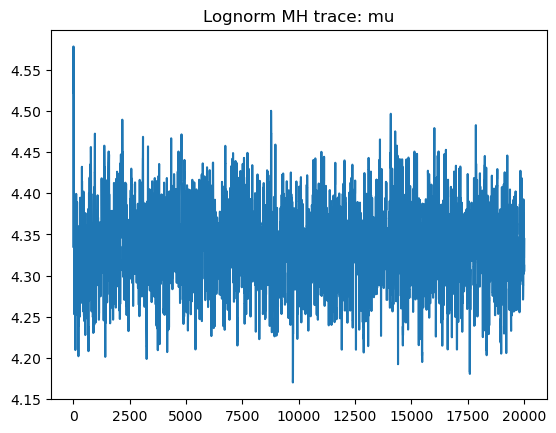

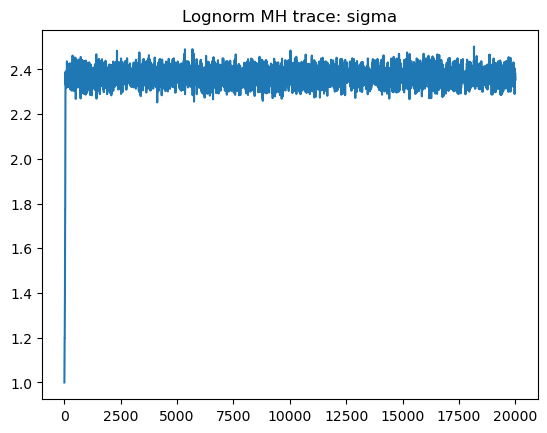

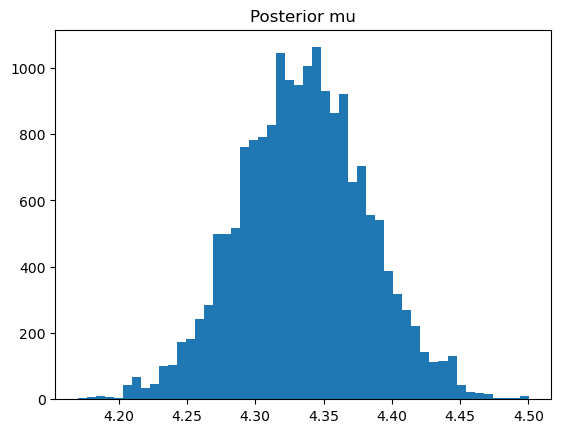

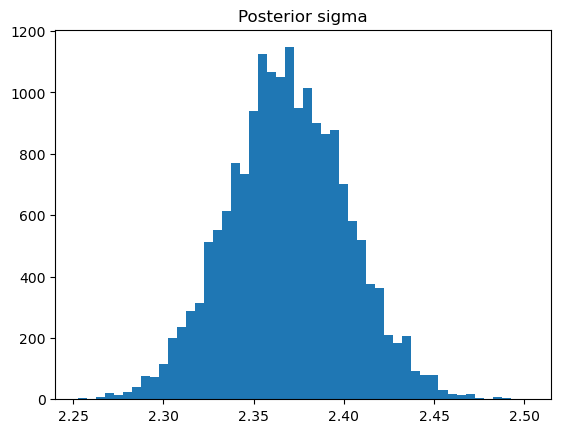

In [25]:
mu_chain = res_lognorm["samples"][:, 0]
sigma_chain = res_lognorm["samples"][:, 1]

plt.plot(mu_chain)
plt.title("Lognorm MH trace: mu")
plt.show()

plt.plot(sigma_chain)
plt.title("Lognorm MH trace: sigma")
plt.show()

plt.hist(res_lognorm["posterior_samples"][:, 0], bins=50)
plt.title("Posterior mu")
plt.show()

plt.hist(res_lognorm["posterior_samples"][:, 1], bins=50)
plt.title("Posterior sigma")
plt.show()

# testing fit_movement_kernel with all step models and bayesian mcmc

In [29]:
res_bayes = mk.fit_step_distribution(
    step_subset,
    method="bayes"
)

res_bayes["distribution"]
res_bayes["waic"]
res_bayes["model_table"]

,distribution,waic
0,lognorm_bayes,34195.070822
1,weibull_bayes,34358.723984
2,gamma_bayes,34503.834202
3,exp_bayes,37746.910010


In [30]:
out = mk.fit_movement_kernel_per_id(
    reloc,
    step_method="bayes",
    proposal_sd=0.05,
)
out["summary"].head()

,ID,n_steps,step_distribution,step_q25,step_median,step_mean,step_q75,step_max,n_angles,angle_distribution,step_waic,step_acceptance_rate,vonmises_kappa,vonmises_mu,mixture_kappa,mixture_w
0,NPL38,2584,lognorm_bayes,8.809685,63.692252,546.335874,760.120739,7014.598776,2252,angle_mle,34195.141002,0.25795,0.135231,0.093184,6.79407,0.103583


# testing bayesian angle models

In [164]:
res_mix_bayes = mh.fit_vm_uniform_distribution_bayes(angle_subset)

res_mix_bayes

{'n': 2252,
 'distribution': 'vm_uniform_bayes',
 'posterior_mean_kappa': 6.960472913027316,
 'posterior_median_kappa': 6.598902203683905,
 'posterior_q025_kappa': 4.008284355273496,
 'posterior_q975_kappa': 11.961894115955797,
 'posterior_mean_w': 0.10243148317126582,
 'posterior_median_w': 0.102089255581906,
 'posterior_q025_w': 0.07284426393659713,
 'posterior_q975_w': 0.13401358556866658,
 'posterior_mean_params': (6.960472913027316, 0.10243148317126582),
 'posterior_median_params': (6.598902203683905, 0.102089255581906),
 'posterior_q025_params': (4.008284355273496, 0.07284426393659713),
 'posterior_q975_params': (11.961894115955797, 0.13401358556866658),
 'acceptance_rate': 0.37525,
 'init_params': (1.0, 0.5),
 'proposal_sd': 0.3,
 'prior_scale': 10.0,
 'samples': array([[0.74121913, 0.40394747],
        [0.74121913, 0.40394747],
        [0.74121913, 0.40394747],
        ...,
        [7.26700456, 0.10068342],
        [7.61652328, 0.10644906],
        [7.61652328, 0.10644906]]),
 

# testing bayesian mcmc in general

In [14]:
out_angle_auto = mk.fit_movement_kernel_per_id(
    reloc,
    step_method="bayes",
    angle_method="bayes",
)

out_angle_auto["summary"].head()

,ID,n_steps,step_distribution,step_q25,step_median,step_mean,step_q75,step_max,n_angles,angle_distribution,...,angle_waic,angle_acceptance_rate,angle_posterior_mean_kappa,angle_posterior_median_kappa,angle_posterior_q025_kappa,angle_posterior_q975_kappa,angle_posterior_mean_w,angle_posterior_median_w,angle_posterior_q025_w,angle_posterior_q975_w
0,NPL38,2584,lognorm_bayes,8.809685,63.692252,546.335874,760.120739,7014.598776,2252,vm_uniform_bayes,...,8205.330458,0.36765,7.082058,6.707836,4.043312,12.20565,0.10209,0.10183,0.072828,0.134258


In [26]:
res_angle_bayes = mk.fit_turn_angle_distribution(
    angle_subset,
    method="bayes",
    bayes_model=None,
    proposal_sd=0.1,
)

res_angle_bayes["distribution"]
res_angle_bayes["waic"]
res_angle_bayes["model_table"]

,distribution,waic
0,vm_uniform_bayes,8198.21592
1,vonmises_bayes,8253.56949
